In [1]:
import pickle
import pandas as pd
df = pd.read_pickle('resultados_ragas.pkl')
df

,id,input_usuario,demanda,pergunta_critica_1,pergunta_critica_2,documentos_retornados_rag,resposta_gerada,veredito_validador,fonte_verificada,referencias,faithfulness,answer_relevancy,context_precision,resposta_baseline,answer_relevancy_baseline,grupo
0,1,É verdade que paracetamol causa autismo? Se o ...,Qual é o consenso científico atual sobre a seg...,Existe evidência científica robusta que estabe...,A afirmação feita pela figura pública citada é...,[ANO: 2025 | FONTE_VERIFICADA: True | FONTE: a...,O paracetamol continua sendo considerado o ana...,ADEQUADO,True,[https://www.agencialupa.org/jornalismo/2025/0...,1.000000,0.731821,1.0,A resposta curta é **não**. Não existe nenhuma...,0.628508,1
1,2,O detergente Ypê estava contaminado por bactér...,Quais são os protocolos de segurança e os proc...,Existe uma relação de causalidade entre a regu...,Qual é o respaldo oficial sobre o caso de cont...,[ANO: 2024 | FONTE_VERIFICADA: True | FONTE: a...,A segurança sanitária no Brasil é garantida po...,ADEQUADO,True,[https://www.aosfatos.org/noticias/falso-anvis...,0.583333,0.797245,1.0,A sua preocupação toca em um ponto fundamental...,0.918824,1
2,3,O alumínio é liberado na comida quando aquecid...,Qual é o risco real à saúde humana associado à...,Existe evidência científica que comprove que a...,Quais são as diretrizes de órgãos de saúde e s...,[],,INADEQUADO,False,[],NaN,NaN,NaN,"Essa é uma questão que envolve química, saúde ...",0.796293,1
3,4,O governo suspendeu a nova vacina contra dengu...,Quais são as formas cientificamente comprovada...,Quais são os critérios técnicos e científicos ...,Existe uma relação de causalidade comprovada e...,[ANO: 2026 | FONTE_VERIFICADA: True | FONTE: g...,É perfeitamente compreensível que você sinta a...,ADEQUADO,True,[https://www.gov.br/saude/pt-br/assuntos/saude...,0.862069,0.812681,1.0,"Essa é uma questão que envolve química, saúde ...",0.674495,1
4,5,O nipah tá se espalhando no mundo. Fui no carn...,Quais são as formas de transmissão do vírus Ni...,Qual é a atual situação epidemiológica do víru...,Quais são as formas de transmissão confirmadas...,[ANO: 2026 | FONTE_VERIFICADA: True | FONTE: c...,É perfeitamente compreensível que você sinta a...,ADEQUADO,True,[https://www.aosfatos.org/noticias/o-que-e-vir...,0.680000,0.760476,1.0,É importante esclarecer alguns pontos sobre o ...,0.509158,1
5,6,A cidade de SP que teve água contaminada com m...,Quais são os procedimentos oficiais para verif...,Existe algum registro oficial ou comunicado da...,None,[],,INADEQUADO,False,[],NaN,NaN,NaN,É importante esclarecer um ponto fundamental a...,0.819324,1
6,7,É verdade que arroz vira açúcar no corpo? Mas ...,Qual é o impacto do consumo de arroz nos nívei...,Como o organismo processa o amido presente no ...,None,[],,INADEQUADO,False,[],NaN,NaN,NaN,"A resposta curta é **sim, o arroz vira açúcar ...",0.511636,1
7,8,Li uma postagem no Instagram sobre um estudo q...,Quais são os efeitos do consumo de vinho na mi...,Existe evidência científica robusta que compro...,O consumo de vinho é recomendado por associaçõ...,[ANO: 2026 | FONTE_VERIFICADA: True | FONTE: a...,A higiene bucal eficaz é alcançada exclusivame...,ADEQUADO,True,[https://www.agencialupa.org/verificacao/2026/...,0.545455,0.729209,1.0,"É compreensível que, após grandes eventos como...",0.656615,1
8,9,Me avisaram para não sair no Carnaval por caus...,O que é a 'pneumonia branca' e existe algum su...,Existe registro oficial ou científico de uma n...,None,[ANO: 2026 | FONTE_VERIFICADA: True | FONTE: a...,É perfeitamente compreensível que você se sint...,ADEQUADO,True,[https://www.aosfatos.org/noticias/nao-e-verda...,0.857143,0.852003,1.0,É importante esclarecer um ponto fundamental a...,0.679243,1
9,10,Conheço várias pessoas que fizeram quimio e mo...,Quais são os benefícios e os objetivos clínico...,Quais são os objetivos terapêuticos da quimiot...,Como a literatura científica e os protocolos o...,[],,INADEQUADO,False,[],NaN,NaN,NaN,Sinto muito que você tenh

/tmp/ipykernel_70804/1299031684.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(


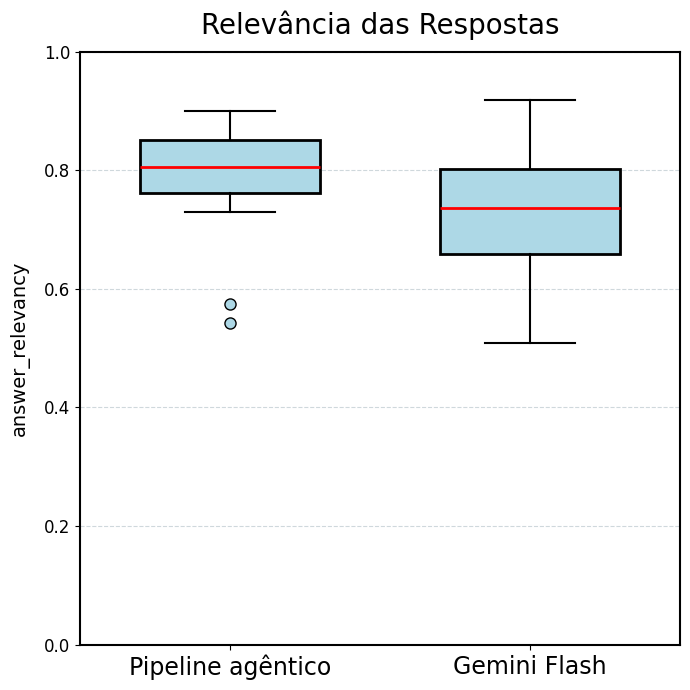

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Configuração Global de Fontes (Mesmo padrão do seu gráfico de barras) ---
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Arial",
    "Helvetica",
    "DejaVu Sans",
    "Liberation Sans",
]

# Carrega o DataFrame do arquivo pickle
df = pd.read_pickle("resultados_ragas.pkl")

# 1. Filtrar os valores nulos (NaN) de cada coluna individualmente
dados_relevancy = df["answer_relevancy"].dropna()
dados_baseline = df["answer_relevancy_baseline"].dropna()

# 2. Agrupar os dados em uma lista para o boxplot
dados_plot = [dados_relevancy, dados_baseline]

# 3. Criar a figura e os eixos (Tamanho ligeiramente ajustado para o padrão do anterior)
fig, ax = plt.subplots(figsize=(7, 7))

# 4. Gerar o boxplot mantendo as cores padrão, mas aplicando bordas pretas nítidas
# O parâmetro boxprops, medianprops, etc., garantem o visual limpo sem estilizações coloridas invasivas
boxplot = ax.boxplot(
    dados_plot,
    labels=["Pipeline agêntico", "Gemini Flash"],
    patch_artist=True,  # Permite aplicar configurações na caixa
    boxprops=dict(facecolor="#ADD8E6", edgecolor="black", linewidth=2.0),
    medianprops=dict(color="red", linewidth=2.0),
    whiskerprops=dict(color="black", linewidth=1.5),
    capprops=dict(color="black", linewidth=1.5),
    flierprops=dict(
        marker="o", markerfacecolor="#ADD8E6", markeredgecolor="black", markersize=8
    ),
    widths=0.6
)

# 5. Configurar labels, títulos e eixos com as fontes ampliadas do seu modelo
ax.set_title("Relevância das Respostas", fontsize=20, pad=13)
ax.set_ylabel("answer_relevancy", fontsize=14, labelpad=10)

# Tamanho dos números e nomes nos eixos
ax.tick_params(axis="y", labelsize=12)
ax.set_xticklabels(["Pipeline agêntico", "Gemini Flash"], fontsize=17)
ax.set_ylim(0, 1)
# Linhas de grade de fundo idênticas ao gráfico anterior
ax.grid(True, axis="y", linestyle="--", alpha=0.6, color="#b0bec5")
ax.set_axisbelow(True)  # Garante que a grade fique atrás dos boxplots

# Engrossar também a borda dos eixos do próprio gráfico (Padrão 1.5)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

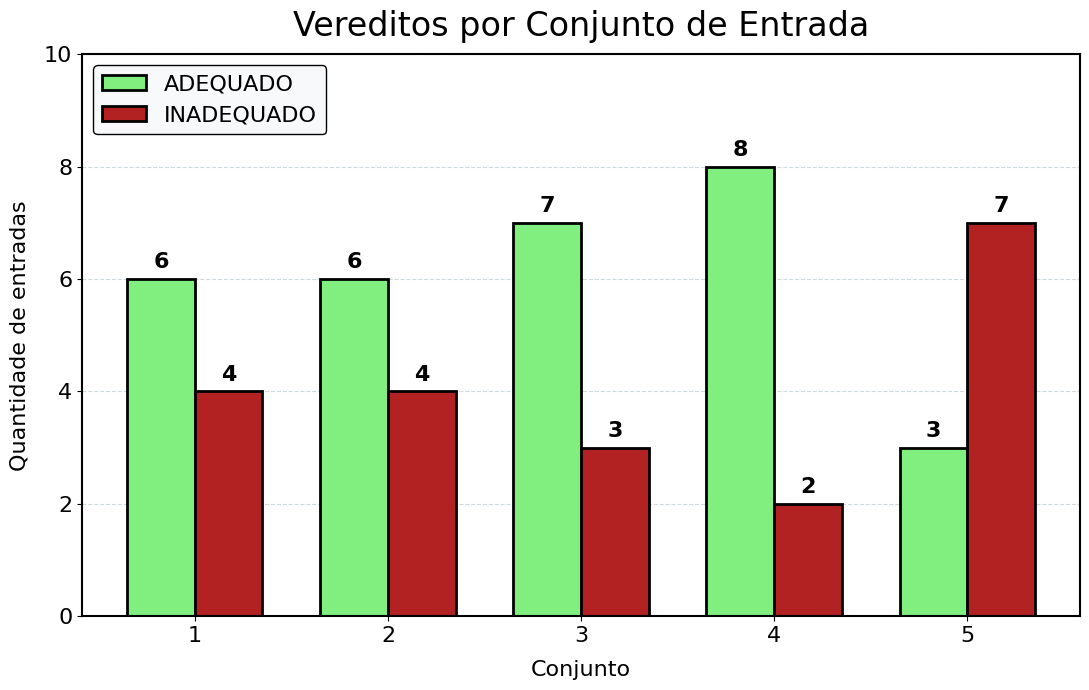

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Configuração Global de Fontes ---
# Define uma família de fontes limpa (sem serifa) e aumenta o tamanho padrão
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Arial",
    "Helvetica",
    "DejaVu Sans",
    "Liberation Sans",
]

# 1. Filtrar e contar os dados agrupados (Mantido o seu padrão)
contagens = pd.crosstab(df["grupo"], df["veredito_validador"])

for coluna in ["ADEQUADO", "INADEQUADO"]:
    if coluna not in contagens.columns:
        contagens[coluna] = 0

contagens = contagens[["ADEQUADO", "INADEQUADO"]]

# 2. Configurar a posição das barras duplas
grupos = contagens.index
x = np.arange(len(grupos))
largura = 0.35

# 3. Criar a figura e os eixos
fig, ax = plt.subplots(figsize=(11, 7))

# 4. Plotar as duas colunas com cores específicas e bordas fortes
# ADEQUADO -> Verde (#2ece6d) | INADEQUADO -> Vermelho (#e74c3c)
barra1 = ax.bar(
    x - largura / 2,
    contagens["ADEQUADO"],
    largura,
    label="ADEQUADO",
    color="#80EF80",
    edgecolor="black",
    linewidth=2.0
)

barra2 = ax.bar(
    x + largura / 2,
    contagens["INADEQUADO"],
    largura,
    label="INADEQUADO",
    color="#B22222",
    edgecolor="black",
    linewidth=2.0
)

# 5. Configurar labels, títulos e eixos com fontes ampliadas
ax.set_title(
    "Vereditos por Conjunto de Entrada", fontsize=24, pad=13
)
ax.set_xlabel("Conjunto", fontsize=16, labelpad=10)
ax.set_ylabel(
    "Quantidade de entradas", fontsize=16, labelpad=10
)

ax.set_xticks(x)
ax.set_xticklabels(grupos, fontsize=16)
ax.tick_params(axis="y", labelsize=16)

ax.set_ylim(0,10)

# Legenda com fonte maior
ax.legend(fontsize=16, edgecolor="black", facecolor="#f8f9fa", loc="upper left", framealpha=1)

# Linhas de grade de fundo um pouco mais visíveis
ax.grid(True, axis="y", linestyle="--", alpha=0.6, color="#b0bec5")
ax.set_axisbelow(True)  # Garante que a grade fique atrás das barras

# 6. Adicionar os valores em cima de cada barra (com fonte maior e em negrito)
ax.bar_label(barra1, padding=5, fontsize=16, fontweight="bold")
ax.bar_label(barra2, padding=5, fontsize=16, fontweight="bold")

# Engrossar também a borda dos eixos do próprio gráfico
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

In [2]:
media_relevancy = df["answer_relevancy"].mean()
media_baseline = df["answer_relevancy_baseline"].mean()

# Imprimir os resultados formatados
print(f"Média - Answer Relevancy: {media_relevancy:.4f}")
print(f"Média - Answer Relevancy Baseline: {media_baseline:.4f}")

Média - Answer Relevancy: 0.7931
Média - Answer Relevancy Baseline: 0.7265


In [2]:
std_faithfulness = df["faithfulness"].std()
std_context_precision = df["context_precision"].std()
std_relevancy = df["answer_relevancy"].std()
std_baseline = df["answer_relevancy_baseline"].std()

# Imprimir os resultados formatados
print(f"Desvio Padrão - Faithfulness: {std_faithfulness:.4f}")
print(f"Desvio Padrão - Context Precision: {std_context_precision:.4f}")
print(f"Desvio Padrão - Answer Relevancy: {std_relevancy:.4f}")
print(f"Desvio Padrão - Answer Relevancy Baseline: {std_baseline:.4f}")

Desvio Padrão - Faithfulness: 0.1207
Desvio Padrão - Context Precision: 0.0000
Desvio Padrão - Answer Relevancy: 0.0793
Desvio Padrão - Answer Relevancy Baseline: 0.0932


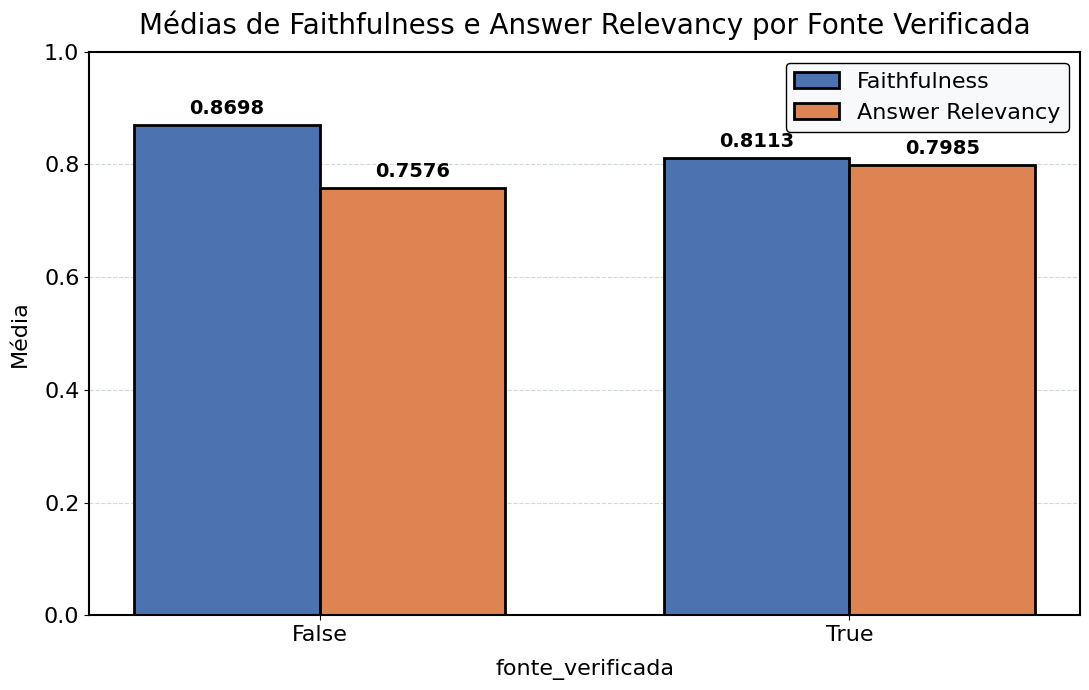

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"]

df = pd.read_pickle("resultados_ragas.pkl")

# Médias por grupo, ignorando NaN
medias = df.groupby("fonte_verificada")[["faithfulness", "answer_relevancy"]].mean()

grupos = ["False", "True"]
medias = medias.reindex([False, True])

x = np.arange(len(grupos))
largura = 0.35

fig, ax = plt.subplots(figsize=(11, 7))

barra1 = ax.bar(
    x - largura / 2,
    medias["faithfulness"],
    largura,
    label="Faithfulness",
    color="#4C72B0",
    edgecolor="black",
    linewidth=2.0
)

barra2 = ax.bar(
    x + largura / 2,
    medias["answer_relevancy"],
    largura,
    label="Answer Relevancy",
    color="#DD8452",
    edgecolor="black",
    linewidth=2.0
)

ax.set_title("Médias de Faithfulness e Answer Relevancy por Fonte Verificada", fontsize=20, pad=13)
ax.set_xlabel("fonte_verificada", fontsize=16, labelpad=10)
ax.set_ylabel("Média", fontsize=16, labelpad=10)

ax.set_xticks(x)
ax.set_xticklabels(grupos, fontsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.set_ylim(0, 1)

ax.legend(fontsize=16, edgecolor="black", facecolor="#f8f9fa", loc="upper right", framealpha=1)

ax.grid(True, axis="y", linestyle="--", alpha=0.6, color="#b0bec5")
ax.set_axisbelow(True)

ax.bar_label(barra1, fmt="%.4f", padding=5, fontsize=14, fontweight="bold")
ax.bar_label(barra2, fmt="%.4f", padding=5, fontsize=14, fontweight="bold")

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


In [6]:
import pandas as pd

df = pd.read_pickle("resultados_ragas.pkl")

print("=== Médias Gerais (ignorando NaN) ===")
print(f"Faithfulness:              {df['faithfulness'].mean():.4f}")
print(f"Answer Relevancy:          {df['answer_relevancy'].mean():.4f}")
print(f"Context Precision:         {df['context_precision'].mean():.4f}")
print(f"Answer Relevancy Baseline: {df['answer_relevancy_baseline'].mean():.4f}")


=== Médias Gerais (ignorando NaN) ===
Faithfulness:              0.8191
Answer Relevancy:          0.7931
Context Precision:         1.0000
Answer Relevancy Baseline: 0.7265


In [7]:
import pandas as pd

df = pd.read_pickle("resultados_ragas.pkl")

print("=== Métricas por fonte_verificada (ignorando NaN) ===")
for valor in [True, False]:
    grupo = df[df["fonte_verificada"] == valor]
    print(f"\nfonte_verificada = {valor}  (n={len(grupo)})")
    print(f"  Faithfulness:              {grupo['faithfulness'].mean():.4f}  (n válidos={grupo['faithfulness'].notna().sum()})")
    print(f"  Answer Relevancy:          {grupo['answer_relevancy'].mean():.4f}  (n válidos={grupo['answer_relevancy'].notna().sum()})")
    print(f"  Context Precision:         {grupo['context_precision'].mean():.4f}  (n válidos={grupo['context_precision'].notna().sum()})")
    print(f"  Answer Relevancy Baseline: {grupo['answer_relevancy_baseline'].mean():.4f}  (n válidos={grupo['answer_relevancy_baseline'].notna().sum()})")


=== Métricas por fonte_verificada (ignorando NaN) ===

fonte_verificada = True  (n=26)
  Faithfulness:              0.8113  (n válidos=26)
  Answer Relevancy:          0.7985  (n válidos=26)
  Context Precision:         1.0000  (n válidos=26)
  Answer Relevancy Baseline: 0.7073  (n válidos=26)

fonte_verificada = False  (n=24)
  Faithfulness:              0.8698  (n válidos=4)
  Answer Relevancy:          0.7576  (n válidos=4)
  Context Precision:         1.0000  (n válidos=4)
  Answer Relevancy Baseline: 0.7472  (n válidos=24)


In [9]:
import pandas as pd

df = pd.read_pickle("resultados_ragas.pkl")

print("=== Métricas por grupo (ignorando NaN) ===")
for valor in ["1", "2", "3", "4", "5"]:
    grupo = df[df["grupo"] == valor]
    print(f"\ngrupo = {valor}  (n={len(grupo)})")
    print(f"  Faithfulness:              {grupo['faithfulness'].mean():.4f}  (n válidos={grupo['faithfulness'].notna().sum()})")
    print(f"  Answer Relevancy:          {grupo['answer_relevancy'].mean():.4f}  (n válidos={grupo['answer_relevancy'].notna().sum()})")
    print(f"  Context Precision:         {grupo['context_precision'].mean():.4f}  (n válidos={grupo['context_precision'].notna().sum()})")
    print(f"  Answer Relevancy Baseline: {grupo['answer_relevancy_baseline'].mean():.4f}  (n válidos={grupo['answer_relevancy_baseline'].notna().sum()})")


=== Métricas por grupo (ignorando NaN) ===

grupo = 1  (n=10)
  Faithfulness:              0.7547  (n válidos=6)
  Answer Relevancy:          0.7806  (n válidos=6)
  Context Precision:         1.0000  (n válidos=6)
  Answer Relevancy Baseline: 0.6874  (n válidos=10)

grupo = 2  (n=10)
  Faithfulness:              0.8377  (n válidos=6)
  Answer Relevancy:          0.7435  (n válidos=6)
  Context Precision:         1.0000  (n válidos=6)
  Answer Relevancy Baseline: 0.6939  (n válidos=10)

grupo = 3  (n=10)
  Faithfulness:              0.8798  (n válidos=7)
  Answer Relevancy:          0.8222  (n válidos=7)
  Context Precision:         1.0000  (n válidos=7)
  Answer Relevancy Baseline: 0.7472  (n válidos=10)

grupo = 4  (n=10)
  Faithfulness:              0.7972  (n válidos=8)
  Answer Relevancy:          0.7984  (n válidos=8)
  Context Precision:         1.0000  (n válidos=8)
  Answer Relevancy Baseline: 0.7617  (n válidos=10)

grupo = 5  (n=10)
  Faithfulness:              0.8275  (n vá